# Практическая работа №5: Элементы регрессионного анализа. Выборочные прямые среднеквадратической регрессии. Корреляционные отношения

Выполнили студенты гр. 2381 Соколов Сергей и Тищенко Артем. Вариант №22

## Цель работы

Ознакомление с основными положениями метода наименьших квадратов (МНК), со статистическими свойствами МНК-оценок, с понятием функции регрессии и роли МНК в регрессионном анализе, с корреляционным отношением, как мерой тесноты произвольной (в том числе и линейной) корреляционной связи.

## Основные теоретические положения

Метод наименьших квадратов (МНК) $-$ метод, основанный на поиске минимума суммы квадратов отклонений значений некоторых функций от заданого множества значений. Он применяется для оценки параметров регрессионных моделей на основе выборочных данных.

Линейная среднеквадратическая регрессия: представим приближенно случайную велечину $Y$ как линейную функцию случайной велечины $X$:

$Y ≈ g(x) = ax + b$

Определим $a$, $b$ через МНК и получим:

$g(x) = m(Y / x) = m(Y) + r_{xy} \frac{\sigma_y}{\sigma_x}[x - m(X)]$

Для выборочных данных:

$\bar{y}_x = \bar{y}_в + \bar{r}_{xy} \frac{S_y}{S_x}(x - \bar{x}_в)$

Для оценки корреляционной зависимости в общем может быть использованно корреляционное отношение $\eta$:

$\bar{\eta}_{xy} = \frac{\bar{\sigma}_{\bar{x}_y}}{\bar{\sigma}_x}$, где $\bar{\sigma}_{\bar{x}_y}$ $-$ СКО $\bar{x}_y$, $\bar{\sigma}_x$ $-$ СКО  $X$

Параболическая среднеквадратическая регрессия:

$\bar{y}_x = ax^2 + bx + c$

Значения коэффициентов $a$, $b$, $c$ находятся с помощью МНК

## Постановка задачи

Для заданной двумерной выборки $(X, Y)$ построить уравнения выборочных прямых среднеквадратической регрессии. Полученные линейные функции регрессии отобразить графически. Найти выборочное корреляционное отношение. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

Подключение библиотек и загрузка выборки

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N = 112
df = pd.read_csv('brigade22.csv')
df.head()

,nu,E
0,434,108.7
1,463,129.1
2,444,130.0
3,408,110.0
4,478,136.6


### Задание 1
Отобразить двумерную выборку на графике.

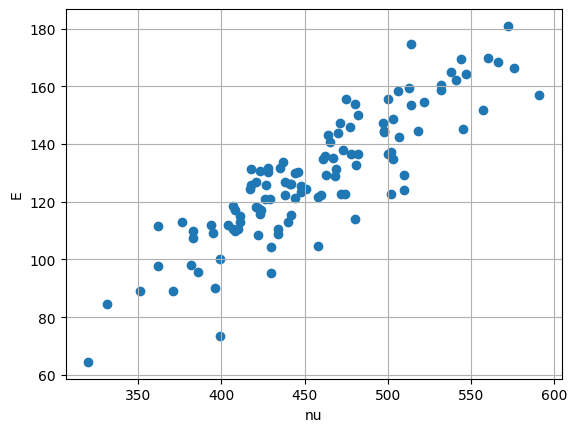

In [19]:
plt.scatter(df['nu'], df['E'])
plt.xlabel('nu')
plt.ylabel('E')
plt.grid()
plt.show()

### Задание 2
Для заданной выборки построить уравнения средней квадратичной регрессии $x$ на $y$ и $y$ на $x$ соответственно. Построить полученные прямые на множестве выборки. Объяснить результаты.

Из предыдущих ПР возьмем значения для выборочных средних, исправленных СКО и коэффициент корреляции величин $\nu$ и $E$

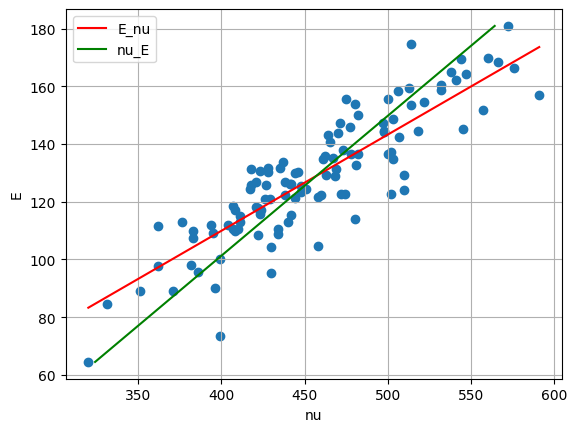

In [22]:
# Выборочное среденее nu из ПР2
nuv = 457.0122767857141
# Выборочное среденее E из ПР4
Ev = 128.93571428571428
# Исправленное СКО nu из ПР2
snu = 54.92160019284322
# Исправленное СКО E из ПР4
sE = 22.07172320529061
# Коэффициент корреляции из ПР4
r = 0.8291518965425814

nu_space = np.linspace(df['nu'].min(), df['nu'].max(), 112)
E_space = np.linspace(df['E'].min(), df['E'].max(), 112)

plt.scatter(df['nu'], df['E'])

# Постороение линейной среднеквадратической регрессии E на nu
plt.plot(nu_space, Ev + r * sE / snu * (nu_space - nuv), color='red', label='E_nu')
# Постороение линейной среднеквадратической регрессии nu на E
plt.plot(nuv + r * snu / sE * (E_space - Ev), E_space, color='green', label='nu_E')

plt.xlabel('nu')
plt.ylabel('E')
plt.grid()
plt.legend()
plt.show()

Обе прямые проходят вдоль выборки, при этом прямые не совпадают, а пересекаются в точке $(\bar{\nu}_в, \bar{E}_в)$. Это происходит в следствии того, что величины зависимы корреляционно, но не функционально.

### Задание 3
Составить корреляционную таблицу для нахождения выборочного корреляционного отношения. Убедиться, что неравенства $\eta_{xy} \geq |r_{xy}|$ и $\eta_{yx} \geq |r_{xy}|$ выполняются.

In [68]:
def get_mid(period: str):
  return np.round(sum(list(map(float, period[1:-1].split(';')))) / 2, 5)

Загрузка корреляционной таблицы из ПР4

In [69]:
df2 = pd.read_csv('corr_table.csv', index_col=0)
E_mids = np.array(list(map(get_mid, df2.index[:-1])))
nu_mids = np.array(list(map(get_mid, df2.columns[:-1])))
df2.loc['Ev_nu'] = (df2.iloc[:-1,:-1].multiply(E_mids, axis=0)).sum(axis=0) / df2.loc['n_nu']
df2.loc[:, 'nuv_E'] = (df2.iloc[:-2,:-1].multiply(nu_mids, axis=1)).sum(axis=1) / df2.loc[:, 'n_E']
df2

,[320.0; 353.875),[353.875; 387.75),[387.75; 421.625),[421.625; 455.5),[455.5; 489.375),[489.375; 523.25),[523.25; 557.125),[557.125; 591.0],n_E,nuv_E
[64.50; 79.05),1.000,0.0000,1.000000,0.000000,0.0,0.000,0.000,0.000,2.0,370.812500
[79.05; 93.60),2.000,1.0000,1.000000,0.000000,0.0,0.000,0.000,0.000,4.0,362.343750
[93.60; 108.15),0.000,4.0000,1.000000,2.000000,1.0,0.000,0.000,0.000,8.0,404.687500
[108.15; 122.70),0.000,3.0000,11.000000,12.000000,5.0,1.000,0.000,0.000,32.0,427.976562
[122.70; 137.25),0.000,0.0000,4.000000,14.000000,9.0,5.000,0.000,0.000,32.0,454.441406
[137.25; 151.80),0.000,0.0000,0.000000,0.000000,7.0,6.000,1.000,0.000,14.0,491.794643
[151.80; 166.35),0.000,0.0000,0.000000,0.000000,2.0,5.000,6.000,1.000,14.0,520.830357
[166.35; 180.90],0.000,0.0000,0.000000,0.000000,0.0,1.000,1.000,4.000,6.0,557.125000
n_nu,3.000,8.0000,18.000000,28.000000,24.0,18.000,8.000,5.000,112.0,NaN
Ev_nu,81.475,104.5125,113.808333,121.660714,132.4,144.525,159.075,170.715,NaN,NaN


In [84]:
# Выборочное СКО nu из ПР2
sigma_nu = 54.675864731176944
# Выборочное СКО E из ПР4
sigma_E = 21.972967796260683

D_inter_nu = (((df2.iloc[:-2, -1] - nuv) ** 2) * df2.loc[:, 'n_E']).sum() / N
eta_nuE = np.sqrt(D_inter_nu) / sigma_nu

D_inter_E = (((df2.iloc[-1, :-2] - Ev) ** 2) * df2.loc['n_nu']).sum() / N
eta_Enu = np.sqrt(D_inter_E) / sigma_E

print(f"Выборочное корреляционное отношение nu к E: {eta_nuE}")
print(f"Выборочное корреляционное отношение E к nu: {eta_Enu}")
print(f"Выборочный коэффициент корреляции: {r}")

Выборочное корреляционное отношение nu к E: 0.835803737509148
Выборочное корреляционное отношение E к nu: 0.8359429683201297
Выборочный коэффициент корреляции: 0.8291518965425814


Оба корреляционных отношения больше коэффициента корреляции.

Неравенства выполняются.

### Задание 4
Для заданной выборки построить корреляционную кривую параболического вида $y = \beta_0 + \beta_1 x + \beta_2 x^2$, сделать выводы.

In [98]:
df3 = pd.DataFrame(columns=['nu_mids', 'n_nu', 'Ev_nu'], index=df2.columns[:-2].to_list())
df3['nu_mids'] = nu_mids
df3['n_nu'] = df2.iloc[-2, :-2]
df3['Ev_nu'] = df2.iloc[-1, :-2]
df3['n_nu*nu'] = df3['n_nu'] * df3['nu_mids']
df3['n_nu*nu^2'] = df3['n_nu'] * df3['nu_mids'] ** 2
df3['n_nu*nu^3'] = df3['n_nu'] * df3['nu_mids'] ** 3
df3['n_nu*nu^4'] = df3['n_nu'] * df3['nu_mids'] ** 4
df3['n_nu * Ev_nu'] = df3['n_nu'] * df3['Ev_nu']
df3['n_nu * Ev_nu * nu'] = df3['n_nu'] * df3['Ev_nu'] * df3['nu_mids']
df3['n_nu * Ev_nu * nu^2'] = df3['n_nu'] * df3['Ev_nu'] * df3['nu_mids'] ** 2
df3.loc['∑'] = df3.sum(axis=0)
df3

,nu_mids,n_nu,Ev_nu,n_nu*nu,n_nu*nu^2,n_nu*nu^3,n_nu*nu^4,n_nu * Ev_nu,n_nu * Ev_nu * nu,n_nu * Ev_nu * nu^2
[320.0; 353.875),336.9375,3.0,81.475000,1010.8125,3.405806e+05,1.147544e+08,3.866506e+10,244.425,8.235595e+04,2.774881e+07
[353.875; 387.75),370.8125,8.0,104.512500,2966.5000,1.100015e+06,4.078994e+08,1.512542e+11,836.100,3.100363e+05,1.149653e+08
[387.75; 421.625),404.6875,18.0,113.808333,7284.3750,2.947896e+06,1.192976e+09,4.827827e+11,2048.550,8.290226e+05,3.354951e+08
[421.625; 455.5),438.5625,28.0,121.660714,12279.7500,5.385438e+06,2.361851e+09,1.035819e+12,3406.500,1.493963e+06,6.551962e+08
[455.5; 489.375),472.4375,24.0,132.400000,11338.5000,5.356733e+06,2.530721e+09,1.195608e+12,3177.600,1.501217e+06,7.092314e+08
[489.375; 523.25),506.3125,18.0,144.525000,9113.6250,4.614342e+06,2.336299e+09,1.182897e+12,2601.450,1.317147e+06,6.668878e+08
[523.25; 557.125),540.1875,8.0,159.075000,4321.5000,2.334420e+06,1.261025e+09,6.811898e+11,1272.600,6.874426e+05,3.713479e+08
[557.125; 591.0],574.0625,5.0,170.715000,2870.3125,1.647739e+06,9.459050e+08,5.430086e+11,853.575,4.900054e+05,2.812937e+08
∑,3644.0000,112.0,1028.171548,51185.3750,2.372716e+07,1.115143e+10,5.311225e+12,14440.800,6.711190e+06,3.162166e+09


In [120]:
A = np.array(
    [
        [df3.loc['∑', 'n_nu*nu^4'], df3.loc['∑', 'n_nu*nu^3'], df3.loc['∑', 'n_nu*nu^2']],
        [df3.loc['∑', 'n_nu*nu^3'], df3.loc['∑', 'n_nu*nu^2'], df3.loc['∑', 'n_nu*nu']],
        [df3.loc['∑', 'n_nu*nu^2'], df3.loc['∑', 'n_nu*nu'], N]
    ]
)
b = np.array([df3.loc['∑', 'n_nu * Ev_nu * nu^2'], df3.loc['∑', 'n_nu * Ev_nu * nu'], df3.loc['∑', 'n_nu * Ev_nu']])
a, b, c = np.linalg.solve(A, b)
print(f'Уравнение выборочных кривых для параболтческой среднеквадратической регрессии: \nE = {c} + {b} * x + {a} * x^2')

Уравнение выборочных кривых для параболтческой среднеквадратической регрессии: 
E = 17.03699983272426 + 0.1549825213057603 * x + 0.0001938629372127108 * x^2


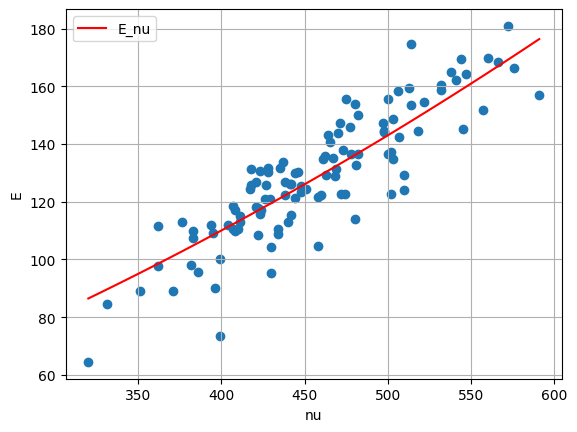

In [123]:
plt.scatter(df['nu'], df['E'])

plt.plot(nu_space, c + b * nu_space + a * nu_space ** 2, color='red', label='E_nu')

plt.xlabel('nu')
plt.ylabel('E')
plt.grid()
plt.legend()
plt.show()

График кривой проходит сквозь выборку, при этом изгиб кривой практически незаметен в виду малого значения параметра $\beta_2$. Из-за чего полученая аппроксимация близка к линейной

### Задание 5
Для заданной выборки построить корреляционную кривую в зависимости от номера варианта и сделать выводы:

Вариант d: логарифмическая функция: $\beta_0 + \beta_1 \ln(x)$

Уравнение корреляционной кривой для логарифмической функции: 
E = -848.8307278735174 + 159.838442495977 * ln(x)


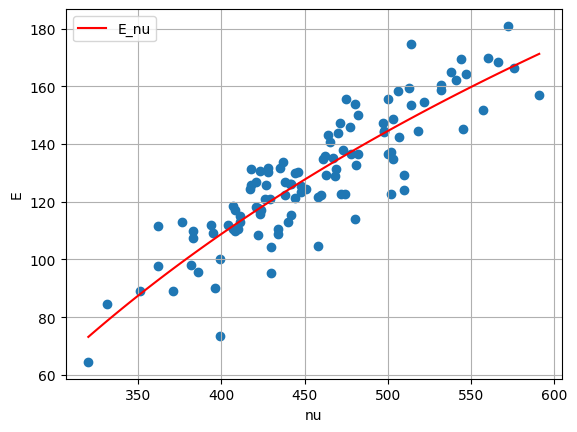

In [130]:
A = np.array([
    df['nu'].map(np.log),
    [1] * N
]).T
E = df['E'].to_numpy()
d, e = np.linalg.inv(A.T @ A) @ A.T @ E

plt.scatter(df['nu'], df['E'])

print(f'Уравнение корреляционной кривой для логарифмической функции: \nE = {e} + {d} * ln(x)')
plt.plot(nu_space, e + d * np.log(nu_space), color='red', label='E_nu')

plt.xlabel('nu')
plt.ylabel('E')
plt.grid()
plt.legend()
plt.show()

График кривой проходит сквозь выборку, при этом изгиб кривой практически незаметен. Из-за чего полуеная аппроксимация близка к линейной

### Задание 6
Вычислить следующие показатели качества регрессии для каждой кривой и сделать выводы:

- теоретический коэффициент детерминации $R^2$;
- средняя квадратическая ошибка $S_ɛ$;
- средняя ошибка аппроксимации (приближения) $A$.

In [128]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

lin = Ev + r * sE / snu * (df['nu'] - nuv)
sqr = c + b * df['nu'] + a * df['nu'] ** 2
log = e + d * np.log(df['nu'])

print(f"Линейная: \nR2: {r2_score(df['E'], lin)}\nS_eps: {mean_squared_error(df['E'], lin)} \nA: {mean_absolute_percentage_error(df['E'], lin)}")
print(f"\nПараболическая: \nR2: {r2_score(df['E'], sqr)}\nS_eps: {mean_squared_error(df['E'], sqr)} \nA: {mean_absolute_percentage_error(df['E'], sqr)}")
print(f"\nЛогарифмическая: \nR2: {r2_score(df['E'], log)}\nS_eps: {mean_squared_error(df['E'], log)} \nA: {mean_absolute_percentage_error(df['E'], log)}")

Линейная: 
R2: 0.7679134366990389
S_eps: 112.41921425606448 
A: 0.06777233756070525

Параболическая: 
R2: 0.7635016340814186
S_eps: 114.55622458820754 
A: 0.06861252304022908

Логарифмическая: 
R2: 0.771992244830554
S_eps: 110.44350140683953 
A: 0.06687730867476849


Все регрессии имеют примерно равные значения показателей качества.

## Выводы

Была найдена статистическая оценка корреляционного отношения заданой выборки. Были построены линейная, параболическая и логарифмическая функции регрессии $E$ относительно $\nu$. Для каждой регрессии были посчитаны показатели качества, из которых видно, что все регрессии приближают значения функции примерно одинаковы.   